In [2]:
import os
import json
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer
import matplotlib.pyplot as plt # 顺便加个画图库，后面可视化用

# 检查显卡状态
device = "cuda:1" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda:1


In [3]:
MODEL_PATH = "Qwen/Qwen3-8B" 

print(f"Loading model and tokenizer from {MODEL_PATH}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH, 
    torch_dtype=torch.bfloat16, 
    device_map=device,
    trust_remote_code=True
)
model.eval() # 切换到评估模式，关闭 Dropout 等机制

num_layers = model.config.num_hidden_layers
hidden_size = model.config.hidden_size
print(f"✅ 模型加载完毕！")
print(f"模型层数: {num_layers}, 隐藏层维度(Hidden Size): {hidden_size}")

Loading model and tokenizer from Qwen/Qwen3-8B...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

✅ 模型加载完毕！
模型层数: 36, 隐藏层维度(Hidden Size): 4096


In [17]:
# 将路径替换为 Wikitext 数据集
DATA_PATH = "/home/bev/disk4/haoxuan/SpeculativeDecoding/pruningAnalysis/calibration_data/wikitext_calibration_1000.json"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    calibration_data = json.load(f)

print(f"一共加载了 {len(calibration_data)} 条数据。")

# 提取第一条数据作为我们的“小白鼠”
sample_text = calibration_data[0]
print("\n--- 我们的测试文本 ---")
# 因为 Wikitext 的 chunk 很长，为了排版美观，我们只打印前 500 个字符看看样子
print(sample_text[:500] + "......\n(已截断显示)")
# 将文本转化为 Token ID
inputs = tokenizer(sample_text, return_tensors="pt", truncation=True, max_length=2048).to(device)

input_ids = inputs["input_ids"]
seq_len = input_ids.shape[1]
print(inputs)

一共加载了 1000 条数据。

--- 我们的测试文本 ---
Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and fo......
(已截断显示)
{'input_ids': tensor([[ 19617,     73,  55661,    902,  85162,     88,   4204,    220,     18,
            549,   1230,   8548,    291,  65316,    320,  10769,    549,  49434,
             99,  74167,  15767, 139330,  32610, 135809, 127176,     18,   1154,
          13020,    659,  85162,     88,   4204,    315,    279,  70635,    220,
             18,    873,   1154,  16626,  13862,    311,    438,  85162,     88,
           4204,  65316,  14429, 

In [18]:
with torch.no_grad():
    # 开始前向传播！
    outputs = model(**inputs, output_hidden_states=True)

# 提取隐藏状态
hidden_states = outputs.hidden_states


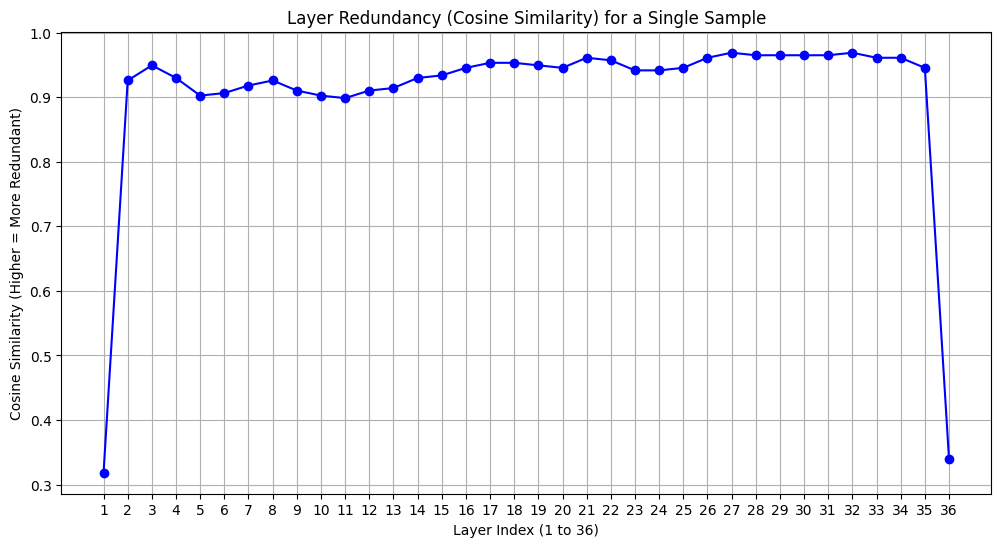

In [19]:
single_sample_sims = []

for i in range(1, num_layers + 1):
    in_state = hidden_states[i-1]
    out_state = hidden_states[i]
    sim = F.cosine_similarity(in_state, out_state, dim=-1).mean().item()
    single_sample_sims.append(sim)

# 画图
plt.figure(figsize=(12, 6))
plt.plot(range(1, num_layers + 1), single_sample_sims, marker='o', linestyle='-', color='b')
plt.title("Layer Redundancy (Cosine Similarity) for a Single Sample")
plt.xlabel("Layer Index (1 to 36)")
plt.ylabel("Cosine Similarity (Higher = More Redundant)")
plt.grid(True)
plt.xticks(range(1, num_layers + 1))
plt.show()

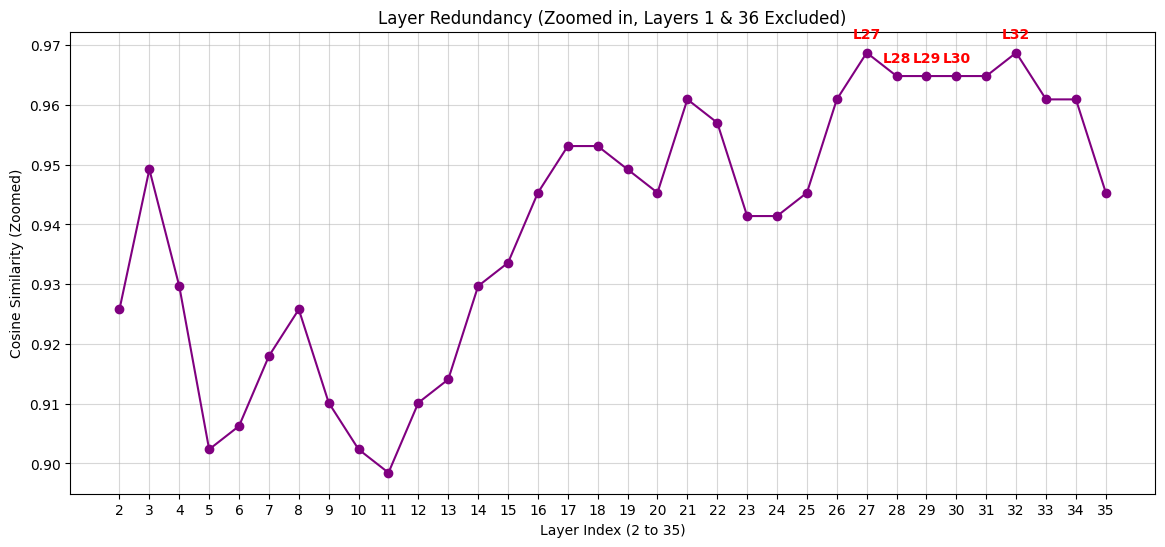

In [20]:
# 忽略掉两头极端的第1层和第36层，放大观察中间层的微小波动
filtered_layers_sim = list(range(2, num_layers)) # 也就是 Layer 2 到 35
filtered_sims = single_sample_sims[1:-1] # 列表切片：去掉第一个和最后一个元素

plt.figure(figsize=(14, 6))
# 换个颜色区分一下
plt.plot(filtered_layers_sim, filtered_sims, marker='o', linestyle='-', color='purple')
plt.title("Layer Redundancy (Zoomed in, Layers 1 & 36 Excluded)")
plt.xlabel("Layer Index (2 to 35)")
plt.ylabel("Cosine Similarity (Zoomed)")
plt.grid(True, alpha=0.5)
plt.xticks(filtered_layers_sim)

# 自动在图中标出最冗余（相似度最高）的几个层，方便你直接看结果
top_redundant = sorted(zip(filtered_layers_sim, filtered_sims), key=lambda x: x[1], reverse=True)[:5]
for layer, sim in top_redundant:
    plt.annotate(f"L{layer}", (layer, sim), textcoords="offset points", xytext=(0,10), ha='center', color='red', weight='bold')

plt.show()

In [16]:
from tqdm.notebook import tqdm # Jupyter 专用的进度条

layer_similarities = {i: 0.0 for i in range(1, num_layers + 1)}
num_samples = 1000 # 我们测 1000 条

with torch.no_grad():
    for text in tqdm(calibration_data[:num_samples], desc="Analyzing Layers"):
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=2048).to(device)
        outputs = model(**inputs, output_hidden_states=True)
        h_states = outputs.hidden_states
        
        for i in range(1, num_layers + 1):
            sim = F.cosine_similarity(h_states[i-1], h_states[i], dim=-1).mean().item()
            layer_similarities[i] += sim

# 计算平均值
for i in range(1, num_layers + 1):
    layer_similarities[i] /= num_samples

# 排序并得出结果
sorted_layers = sorted(layer_similarities.items(), key=lambda x: x[1], reverse=True)
layers_to_prune = sorted([layer_idx for layer_idx, _ in sorted_layers[:18]])
layers_to_keep = sorted([layer_idx for layer_idx, _ in sorted_layers[18:]])

print("\n✂️  最终剪枝方案 (Top 18 最冗余层)")
print(f"建议剪除的层 (Prune): {layers_to_prune}")
print(f"建议保留的层 (Keep) : {layers_to_keep}")

Analyzing Layers:   0%|          | 0/1000 [00:00<?, ?it/s]


✂️  最终剪枝方案 (Top 18 最冗余层)
建议剪除的层 (Prune): [3, 17, 18, 19, 20, 21, 22, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]
建议保留的层 (Keep) : [1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 23, 24, 36]
